Stratégie équipondéré :

--- Statistiques de Performance (Consolidées) ---
          Ann. Return (Log) Ann. Volatility Sharpe Ratio Max Drawdown
Commodity             6.28%           9.51%         0.66      -45.07%
Currency              2.13%           6.26%         0.34      -13.89%
Rate                  2.54%           3.92%         0.65      -12.79%
Equity               13.49%          15.83%         0.85      -38.49%
Portfolio             3.85%           3.56%         1.08      -13.86%

--- Matrice de Corrélation ---
           Commodity  Currency      Rate    Equity
Commodity   1.000000 -0.022197  0.105882 -0.030097
Currency   -0.022197  1.000000 -0.128958 -0.076717
Rate        0.105882 -0.128958  1.000000 -0.141640
Equity     -0.030097 -0.076717 -0.141640  1.000000


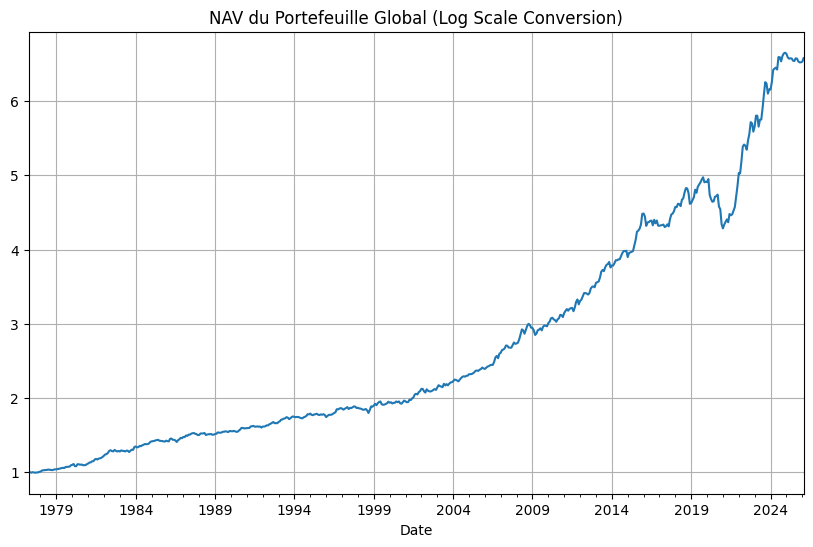

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Chargement des fichiers Excel (Log Returns)
def load_and_clean_excel(file_path, name):
    try:
        df = pd.read_excel(file_path, sheet_name=0)
        df['Date'] = pd.to_datetime(df.iloc[:, 0], errors='coerce')
        df = df.dropna(subset=['Date'])
        df['Date'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')
        df[name] = pd.to_numeric(df.iloc[:, 1], errors='coerce')
        return df[['Date', name]].set_index('Date')
    except Exception as e:
        print(f"Erreur lors du chargement de {name}: {e}")
        return pd.DataFrame()

# 2. Chargement des Equity (Rendements Simples -> Conversion en Log)
def load_equity_strategy(file_path, strategy_name="C_ValueQualityMom"):
    df = pd.read_csv(file_path)
    df_strat = df[df['strategy'] == strategy_name].copy()

    df_strat['Date'] = pd.to_datetime(df_strat['date'], errors='coerce')
    df_strat = df_strat.dropna(subset=['Date'])
    df_strat['Date'] = df_strat['Date'].dt.to_period('M').dt.to_timestamp('M')

    # 'ls_ret' est un rendement simple (ex: 0.05 pour 5%)
    simple_ret = pd.to_numeric(df_strat['ls_ret'], errors='coerce')

    # Transformation en Log Return : log(1 + r)
    # On utilise np.log1p pour la stabilité numérique
    df_strat['Equity'] = np.log1p(simple_ret)

    return df_strat[['Date', 'Equity']].set_index('Date')

# Chemins des fichiers
files = {
    'Commodity': 'Commo_Strategy_Monthly_Returns.xlsx',
    'Currency': 'PPP_Pure_Strategy_Returns_EOM.xlsx',
    'Rate': 'fi_combo_global_quarterly_log_returns.xlsx'
}
csv_path = 'master_allocation.csv'

try:
    # 3. Construction du DataFrame consolidé (Tout en Log Returns désormais)
    strategies_list = [load_and_clean_excel(path, name) for name, path in files.items()]

    # L'Equity est maintenant convertie en Log au sein de la fonction
    df_equity = load_equity_strategy(csv_path)
    strategies_list.append(df_equity)

    # Fusion
    df_log = pd.concat(strategies_list, axis=1).sort_index()

    # 4. Calcul du Portefeuille Equipondéré
    # Pour combiner des actifs, on repasse toujours par l'arithmétique (somme pondérée des rendements simples)
    df_arith = np.expm1(df_log.astype(float)) # équivalent à exp(x) - 1

    weight = 0.25
    # fillna(0) permet de ne pas invalider toute la ligne si une stratégie n'a pas encore démarré
    df_arith['Portfolio'] = df_arith[['Commodity', 'Currency', 'Rate', 'Equity']].fillna(0).sum(axis=1) * weight

    # Reconversion du résultat Portfolio en Log pour les stats cumulées
    df_log['Portfolio'] = np.log1p(df_arith['Portfolio'])

    # 5. Calcul des Métriques de Performance
    def calculate_stats(series):
        s = series.dropna()
        if s.empty: return pd.Series()

        ann_ret = s.mean() * 12
        ann_vol = s.std() * np.sqrt(12)
        sharpe = ann_ret / ann_vol if ann_vol != 0 else 0

        # Calcul du Max Drawdown sur la base de la valeur liquidative (NAV)
        cum_nav = np.exp(s.cumsum())
        peak = cum_nav.cummax()
        drawdown = (cum_nav / peak) - 1
        max_dd = drawdown.min()

        return pd.Series({
            'Ann. Return (Log)': f"{ann_ret:.2%}",
            'Ann. Volatility': f"{ann_vol:.2%}",
            'Sharpe Ratio': round(sharpe, 2),
            'Max Drawdown': f"{max_dd:.2%}"
        })

    stats_performance = df_log.apply(calculate_stats).T

    # Matrice de corrélation (basée sur les log-rendements pour la linéarité)
    assets = ['Commodity', 'Currency', 'Rate', 'Equity']
    correlation_matrix = df_log[assets].corr()

    print("--- Statistiques de Performance (Consolidées) ---")
    print(stats_performance)
    print("\n--- Matrice de Corrélation ---")
    print(correlation_matrix)

    # Visualisation
    (np.exp(df_log['Portfolio'].dropna().cumsum())).plot(figsize=(10,6), title="NAV du Portefeuille Global (Log Scale Conversion)")
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"Erreur rencontrée : {e}")

Vérification des données  :

In [17]:
# --- AJOUT : Aperçu des données ---
print("\n--- Aperçu des 5 premières lignes du DataFrame consolidé (Log Returns) ---")
print(df_log.head())

print("\n--- Aperçu des 5 dernières lignes du DataFrame consolidé (Log Returns) ---")
print(df_log.tail())

print("\n--- Nombre de données disponibles par stratégie ---")
print(df_log.count()) # Compte les valeurs non-nulles pour chaque colonne
# ----------------------------------


--- Aperçu des 5 premières lignes du DataFrame consolidé (Log Returns) ---
            Commodity  Currency  Rate  Equity  Portfolio
Date                                                    
1977-04-30  -0.024543       NaN   NaN     NaN  -0.006080
1977-05-31   0.012429       NaN   NaN     NaN   0.003122
1977-06-30  -0.024227       NaN   NaN     NaN  -0.006002
1977-07-31   0.024766       NaN   NaN     NaN   0.006249
1977-08-31  -0.012275       NaN   NaN     NaN  -0.003055

--- Aperçu des 5 dernières lignes du DataFrame consolidé (Log Returns) ---
            Commodity  Currency      Rate  Equity  Portfolio
Date                                                        
2025-10-31  -0.025041       NaN  0.001905     NaN  -0.005722
2025-11-30  -0.010101       NaN  0.002133     NaN  -0.001981
2025-12-31  -0.000394       NaN  0.000845     NaN   0.000113
2026-01-31   0.006056       NaN -0.000979     NaN   0.001273
2026-02-28   0.025153       NaN  0.004213     NaN   0.007396

--- Nombre de données

Stratégie active :


--- PÉRIODE D'ANALYSE GLOBALE : 2006-01 à 2024-10 ---

--- STATISTIQUES IN-SAMPLE (Entraînement Macro : jusqu'à fin 2019) ---
                  Ann. Return (Log) Ann. Volatility Sharpe Ratio Max Drawdown
Portfolio_Naive               5.13%           3.76%         1.36       -4.99%
Portfolio_Dynamic             6.93%           3.53%         1.96       -2.59%

--- STATISTIQUES OUT-OF-SAMPLE (Test Macro : 2020 - 2026) ---
                  Ann. Return (Log) Ann. Volatility Sharpe Ratio Max Drawdown
Portfolio_Naive               6.13%           6.45%         0.95      -13.44%
Portfolio_Dynamic            10.51%           8.16%         1.29       -7.68%


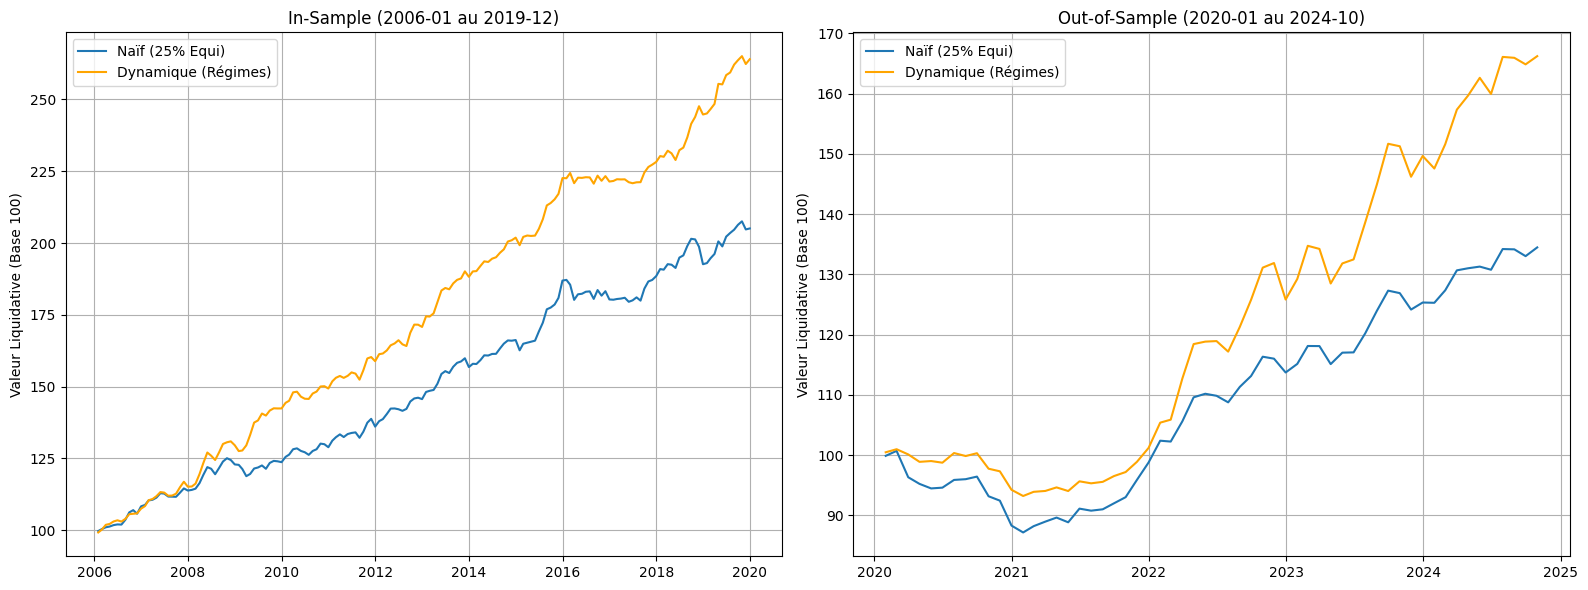

In [18]:
# --- AJOUT : ALLOCATION DYNAMIQUE (PÉRIODE COMPLÈTE & SÉPARATION IS/OOS) ---

# 1. Chargement et alignement temporel des régimes macroéconomiques
try:
    df_regimes = pd.read_csv('macro_regimes.csv')
    df_regimes['date'] = pd.to_datetime(df_regimes['date'], errors='coerce')
    df_regimes = df_regimes.dropna(subset=['date'])
    df_regimes['date'] = df_regimes['date'].dt.to_period('M').dt.to_timestamp('M')
    df_regimes = df_regimes.set_index('date')

    # Jointure des régimes avec les rendements arithmétiques
    df_arith = df_arith.join(df_regimes['regime'], how='left')
except Exception as e:
    print(f"Erreur lors du chargement des régimes : {e}")

# 2. Restriction stricte à la période avec l'intégralité des données
assets = ['Commodity', 'Currency', 'Rate', 'Equity']

# On supprime toutes les dates où il manque au moins un rendement d'actif OU un régime macro
df_arith_complete = df_arith.dropna(subset=assets + ['regime']).copy()

# On met à jour df_log pour qu'il corresponde exactement à ce sous-ensemble temporel
df_log_complete = df_log.loc[df_arith_complete.index].copy()

# 3. Dictionnaire des pondérations
regime_weights = {
    "goldilocks":  {"Equity": 0.16, "Rate": 0.10, "Currency": 0.24, "Commodity": 0.50},
    "reflation":   {"Equity": 0.17, "Rate": 0.50, "Currency": 0.17, "Commodity": 0.16},
    "stagflation": {"Equity": 0.45, "Rate": 0.32, "Currency": 0.10, "Commodity": 0.13},
    "crisis":      {"Equity": 0.10, "Rate": 0.29, "Currency": 0.50, "Commodity": 0.11},
    "slowdown":    {"Equity": 0.18, "Rate": 0.50, "Currency": 0.15, "Commodity": 0.17},
}

# 4. Calcul des rendements du Portefeuille Dynamique et du Naïf
def calculate_dynamic_return(row):
    # Puisque nous avons fait un dropna, le régime existe forcément ici
    regime = row['regime']
    weights = regime_weights[regime]
    return sum(row[asset] * weights[asset] for asset in assets)

# Stratégie Dynamique
df_arith_complete['Portfolio_Dynamic'] = df_arith_complete.apply(calculate_dynamic_return, axis=1)
df_log_complete['Portfolio_Dynamic'] = np.log1p(df_arith_complete['Portfolio_Dynamic'])

# Stratégie Naïve (Equipondérée stricte sur la même période)
df_arith_complete['Portfolio_Naive'] = df_arith_complete[assets].mean(axis=1)
df_log_complete['Portfolio_Naive'] = np.log1p(df_arith_complete['Portfolio_Naive'])

# 5. Séparation In-Sample (Entraînement) et Out-of-Sample (Test)
# En accord avec ton notebook ML, la séparation se fait à fin 2019
TRAIN_END = "2019-12-31"

df_log_is = df_log_complete.loc[:TRAIN_END]
df_log_oos = df_log_complete.loc["2020-01-01":]

# 6. Affichage des statistiques comparatives
print(f"\n--- PÉRIODE D'ANALYSE GLOBALE : {df_log_complete.index.min().strftime('%Y-%m')} à {df_log_complete.index.max().strftime('%Y-%m')} ---")

print("\n--- STATISTIQUES IN-SAMPLE (Entraînement Macro : jusqu'à fin 2019) ---")
stats_is = df_log_is[['Portfolio_Naive', 'Portfolio_Dynamic']].apply(calculate_stats).T
print(stats_is)

print("\n--- STATISTIQUES OUT-OF-SAMPLE (Test Macro : 2020 - 2026) ---")
stats_oos = df_log_oos[['Portfolio_Naive', 'Portfolio_Dynamic']].apply(calculate_stats).T
print(stats_oos)

# 7. Visualisation (Base 100 à chaque début de période)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique In-Sample
axes[0].plot(np.exp(df_log_is['Portfolio_Naive'].cumsum()) * 100, label="Naïf (25% Equi)")
axes[0].plot(np.exp(df_log_is['Portfolio_Dynamic'].cumsum()) * 100, label="Dynamique (Régimes)", color='orange')
axes[0].set_title(f"In-Sample ({df_log_is.index.min().strftime('%Y-%m')} au {df_log_is.index.max().strftime('%Y-%m')})")
axes[0].set_ylabel("Valeur Liquidative (Base 100)")
axes[0].legend()
axes[0].grid(True)

# Graphique Out-of-Sample
axes[1].plot(np.exp(df_log_oos['Portfolio_Naive'].cumsum()) * 100, label="Naïf (25% Equi)")
axes[1].plot(np.exp(df_log_oos['Portfolio_Dynamic'].cumsum()) * 100, label="Dynamique (Régimes)", color='orange')
axes[1].set_title(f"Out-of-Sample ({df_log_oos.index.min().strftime('%Y-%m')} au {df_log_oos.index.max().strftime('%Y-%m')})")
axes[1].set_ylabel("Valeur Liquidative (Base 100)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()